In [1]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 10.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/MyDrive/')

Mounted at /content/MyDrive/


In [3]:
file_path = '/content/MyDrive/MyDrive/Dataset/Movie_Review_Dataset/aclImdb_v1.tar.gz'

In [4]:
import os

# Define a local directory for faster extraction
local_output_dir = '/content/Movie_Review_Dataset'
os.makedirs(local_output_dir, exist_ok=True)

In [5]:
# Extract the archive to the local directory
! tar xzf {file_path} --skip-old-files -C {local_output_dir}

In [6]:
!rm -r /content/Movie_Review_Dataset/aclImdb/train/unsup

We use the helper function "load_files" in scikit-learn to load files stored in train dataset.

In [7]:
from sklearn.datasets import load_files

# load_files returns a bunch, containing training texts and training labels
reviews_train = load_files("/content/Movie_Review_Dataset/aclImdb/train/")

In [8]:
text_train, y_train = reviews_train.data, reviews_train.target

print("Type of text_train: {}".format(type(text_train)))
print("Length of text_train: {}".format(len(text_train)))
print("text_train[6]: \n{}]".format(text_train[6]))

Type of text_train: <class 'list'>
Length of text_train: 25000
text_train[6]: 
b"This movie has a special way of telling the story, at first i found it rather odd as it jumped through time and I had no idea whats happening.<br /><br />Anyway the story line was although simple, but still very real and touching. You met someone the first time, you fell in love completely, but broke up at last and promoted a deadly agony. Who hasn't go through this? but we will never forget this kind of pain in our life. <br /><br />I would say i am rather touched as two actor has shown great performance in showing the love between the characters. I just wish that the story could be a happy ending."]


We can see that test_train is a list of length 25000,  where each entry is a string containing a review.

We printed the review with index 6 and we can also see that the review contains some HTML line breaks `(<br />).`

These are unlikely to have a large impact on our machine learning models, but it is better to clean the data and remove this formatting.

In [9]:
text_train = [doc.replace(b"<br />", b" ") for doc in text_train]

display(text_train[6])

b"This movie has a special way of telling the story, at first i found it rather odd as it jumped through time and I had no idea whats happening.  Anyway the story line was although simple, but still very real and touching. You met someone the first time, you fell in love completely, but broke up at last and promoted a deadly agony. Who hasn't go through this? but we will never forget this kind of pain in our life.   I would say i am rather touched as two actor has shown great performance in showing the love between the characters. I just wish that the story could be a happy ending."

The **b** prefix indicates a bytes literal. It is used because the text data is stored as bytes, and bytes operations must use bytes patterns rather than Unicode strings.

In [10]:
type(text_train[6])

bytes

The type of the entries of text_train will depend on your Python version. In Python 3, they will be of type bytes which represents a binary encoding of the string data. In Python 2, text_train contains strings.

In [11]:
import numpy as np


print("Samples per class (training): {}".format(np.bincount(y_train)))

Samples per class (training): [12500 12500]


The dataset was collected such that the positive class and the negative class balanced, so that there are as many positive as negative strings.

In [12]:
# Load test dataset in same manner
reviews_test = load_files("/content/Movie_Review_Dataset/aclImdb/test/")

text_test, y_test = reviews_test.data, reviews_test.target

print("Number of documents in test data: {}".format(len(text_test)))
print("Samples per class (test): {}".format(np.bincount(y_test)))

Number of documents in test data: 25000
Samples per class (test): [12500 12500]


In [13]:
text_test = [doc.replace(b"<br />", b" ") for doc in text_test]

# Applying Bag-of-Words to a Toy Dataset

The bag-of-words representation is implemented in **CountVectorizer**, which is a transformer.

Below is a application of it to a toy dataset, consisting of two samples.

In [14]:
bards_words =["The fool doth think he is wise,",
              "but the wise man knows himself to be a fool"]

We import and instantiate the CountVectorizer and fit it to our toy data.

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer()
vect.fit(bards_words)

CountVectorizer()

Fitting the CountVectorizer consists of the tokenization of the training data and building of the vocabulary, which we can access as the **vocabulary_** attribute.

In [16]:
print("Vocabulary Size: {}".format(len(vect.vocabulary_)))
print("Vocabulary Content: \n{}".format(vect.vocabulary_))

Vocabulary Size: 13
Vocabulary Content: 
{'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


The vocabulary consists of 13 words, from "be" to "wise".

To create the bag-of-words representation for the training data, we call the transform method.

In [17]:
bag_of_words = vect.transform(bards_words)

print("bag_of_words: {}".format(repr(bag_of_words)))

bag_of_words: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (2, 13)>


repr() is used to obtain the developer-oriented representation of an object, which shows its type and structure and is useful for debugging, especially for complex objects like sparse matrices.

In [18]:
print("Dense representation of bag_of_words:\n{}".format(
    bag_of_words.toarray()))

Dense representation of bag_of_words:
[[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


# Bag-of-Words for Movie Reviews

In [19]:
vect = CountVectorizer()
vect.fit(text_train)

CountVectorizer()

In [20]:
X_train = vect.transform(text_train)
print("X_train: \n{}".format(repr(X_train)))

X_train: 
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3431196 stored elements and shape (25000, 74849)>


The shape of X_train, the bag-of-words representation of the training data, is 25,000×74,849, indicating that the vocabulary contains 74,849 entries.

Another way to access the vocabulary is using the get_feature_name method of the vectorizer, which returns a convenient list where each entry corresponds to one feature.

In [21]:
feature_names = vect.get_feature_names_out()

print("Number of features: {}".format(len(feature_names)))
print("First 20 features:\n{}".format(feature_names[:20]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 2000th feature:\n{}".format(feature_names[::2000]))

Number of features: 74849
First 20 features:
['00' '000' '0000000000001' '00001' '00015' '000s' '001' '003830' '006'
 '007' '0079' '0080' '0083' '0093638' '00am' '00pm' '00s' '01' '01pm' '02']
Features 20010 to 20030:
['dratted' 'draub' 'draught' 'draughts' 'draughtswoman' 'draw' 'drawback'
 'drawbacks' 'drawer' 'drawers' 'drawing' 'drawings' 'drawl' 'drawled'
 'drawling' 'drawn' 'draws' 'draza' 'dre' 'drea']
Every 2000th feature:
['00' 'aesir' 'aquarian' 'barking' 'blustering' 'bête' 'chicanery'
 'condensing' 'cunning' 'detox' 'draper' 'enshrined' 'favorit' 'freezer'
 'goldman' 'hasan' 'huitieme' 'intelligible' 'kantrowitz' 'lawful' 'maars'
 'megalunged' 'mostey' 'norrland' 'padilla' 'pincher' 'promisingly'
 'receptionist' 'rivals' 'schnaas' 'shunning' 'sparse' 'subset'
 'temptations' 'treatises' 'unproven' 'walkman' 'xylophonist']


 The first 10 entries in the vocabulary are all numbers. All these numbers appear somewhere in the reviews, and are therefore extracted as words.

Most of these numbers don’t have any immediate semantic meaning—apart from "007", which in the particular context of movies is likely to refer to the James Bond character.

Weeding out the meaningful from the nonmeaningful “words” is sometimes tricky. Looking further along in the vocabulary, we find a collection of English words starting with “dra”. You might notice that for "draught", "drawback", and "drawer" both the singular and plural forms are contained in the vocabulary as distinct words. These words have very closely related semantic meanings, and counting them as different words, corresponding to different features, might not be ideal.


Before trying to improve our feature extraction, below is a quantitative measure of performance by actually building a classifier. We have the training labels stored in y_train and the bag-of-words representation of the training data in X_train, so we can train a classifier on this data. For high-dimensional, sparse data like this, linear models like LogisticRegression often work best.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(max_iter=1000)

scores = cross_val_score(lr, X_train, y_train, cv=5)

print("Mean cross-validation accuracy: {:.2f}".format(np.mean(scores)))

Mean cross-validation accuracy: 0.88


We obtain a mean cross-validation score of 88%, which indicates reasonable performance for a balanced binary classification task.

Next we can tune the regularization parameter(C) in LogisticRegression.

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C':[0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(lr, param_grid=param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Cross-Validation Score: {:.2f}".format(grid.best_score_))
print("Best Parameters: ", grid.best_params_)

Best Cross-Validation Score: 0.89
Best Parameters:  {'C': 0.1}


We obtain a cross-validation score of 89% using C=0.1. We can now assess the generalization performance of this parameter setting on the test set.

In [24]:
X_test = vect.transform(text_test)
print("Test set Score: {:.2f}".format(grid.score(X_test, y_train)))

Test set Score: 0.88


Now we can see if we can improve the extraction of words. The CountVectorizer extracts tokens using a regular expression. By default, the regular expression that is used is **"\b\w\w+\b"**.

 This simple mechanism works quite well in practice, but as we saw earlier, we get many uninformative features (like the numbers). One way to cut back on these is to only use tokens that appear in at least two documents (or at least five documents, and so on). A token that appears only in a single document is unlikely to appear in the test set and is therefore not helpful.

 We can set the minimum number of documents a token needs to appear in with the **min_df** parameter


In [25]:
vect = CountVectorizer(min_df=5)
vect.fit(text_train)

X_train = vect.transform(text_train)

print("X_train with min_df: {}".format(repr(X_train)))

X_train with min_df: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3354014 stored elements and shape (25000, 27271)>


By requiring at least five appearances of each token, we can bring down the number of features to 27,271, as seen in the preceding output.

In [26]:
feature_names = vect.get_feature_names_out()

print("Number of Features: ",len(feature_names))
print("First 50 Features: \n{}".format(feature_names[:50]))
print("Features from 20010 to 20030: \n{}".format(feature_names[20010:20030]))
print("Every 700th Feature: \n{}".format(feature_names[::700]))

Number of Features:  27271
First 50 Features: 
['00' '000' '007' '00s' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10'
 '100' '1000' '100th' '101' '102' '103' '104' '105' '107' '108' '10s'
 '10th' '11' '110' '112' '116' '117' '11th' '12' '120' '12th' '13' '135'
 '13th' '14' '140' '14th' '15' '150' '15th' '16' '160' '1600' '16mm' '16s'
 '16th']
Features from 20010 to 20030: 
['repentance' 'repercussions' 'repertoire' 'repetition' 'repetitions'
 'repetitious' 'repetitive' 'rephrase' 'replace' 'replaced' 'replacement'
 'replaces' 'replacing' 'replay' 'replayable' 'replayed' 'replaying'
 'replays' 'replete' 'replica']
Every 700th Feature: 
['00' 'affections' 'appropriately' 'barbra' 'blurbs' 'butchered' 'cheese'
 'commitment' 'courts' 'deconstructed' 'disgraceful' 'dvds' 'eschews'
 'fell' 'freezer' 'goriest' 'hauser' 'hungary' 'insinuate' 'juggle'
 'leering' 'maelstrom' 'messiah' 'music' 'occasional' 'parking'
 'pleasantville' 'pronunciation' 'recipient' 'reviews' 'sas' 'shea'
 'sneers' 

There are clearly many fewer numbers, and some of the more obscure words or misspellings seem to have vanished.

We can again see how does the model perform.

In [27]:
grid = GridSearchCV(lr, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Cross-Validation Score: {:.2f}".format(grid.best_score_))

Best Cross-Validation Score: 0.89


The best validation accuracy of the grid search is still 89%, unchanged from before. We didn’t improve our model, but having fewer features to deal with speeds up processing and throwing away useless features might make the model more interpretable.

# Stopwords

Stopwords are commonly occurring words that carry little semantic meaning and are often removed during text preprocessing to reduce noise (data that does not help the model make better predictions) and improve model performance.

we can get rid of these uninformative words. There are two main approaches: using a language-specific list of stopwords, or discarding words that appear too frequently.




In [28]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print("Number of Stop Words: ",len(ENGLISH_STOP_WORDS))
print("Every 10th Stop Word: \n{}".format(list(ENGLISH_STOP_WORDS)[::10]))

Number of Stop Words:  318
Every 10th Stop Word: 
['up', 'amongst', 'empty', 'will', 'a', 'whereafter', 'those', 'we', 'whole', 'ie', 'else', 'of', 'co', 'elsewhere', 'noone', 'sometimes', 'indeed', 'everything', 'nor', 'almost', 'you', 'each', 'hence', 'thereupon', 'or', 'might', 'somewhere', 'from', 'hereupon', 'it', 'their', 'anyway']


Clearly, removing the stopwords in the list can only decrease the number of features by the length of the list here (318), but it might lead to an improvement in performance.

We can run grid search again and see.

In [29]:
# Specifying stop_words="english" uses the built-in list.
# We could also augment it and pass our own.
vect = CountVectorizer(min_df=5, stop_words="english")
vect.fit(text_train)

X_train = vect.transform(text_train)

print("X_train with stop words:\n{}".format(repr(X_train)))

X_train with stop words:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2149958 stored elements and shape (25000, 26966)>


There are now 305 (27,271–26,966) fewer features in the dataset, which means that most, but not all, of the stopwords appeared.

In [30]:
grid = GridSearchCV(lr, param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

Best cross-validation score: 0.88


The grid search performance decreased slightly using the stopwords, not enough to worry about.

Excluding 305 features out of over 27,000 is unlikely to change performance or interpretability a lot, it doesn’t seem worth using this list. Fixed lists are mostly helpful for small datasets, which might not contain enough information for the model to determine which words are stopwords from the data itself.

We can try out the other approach, discarding frequently appearing words, by setting the max_df option of CountVectorizer.

max_df controls how frequent a word is allowed to be before we remove it.we can set a float or a integer value for it

CountVectorizer(max_df=0.95) --> Remove words that appear in more than 95% of documents.

CountVectorizer(max_df=1000) --> Remove words that appear in more than 1000 documents.

In [31]:
# Only words that appear in at least in 5 docs but not more than
vect = CountVectorizer(min_df=5, max_df=0.9)
vect.fit(text_train)

X_train = vect.transform(text_train)

print("X_train with max_df: /n{}".format(repr(X_train)))

X_train with max_df: /n<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3235216 stored elements and shape (25000, 27266)>


In [32]:
grid = GridSearchCV(lr, param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

Best cross-validation score: 0.89


# Rescaling the Data with TF-IDF (Term Frequency–Inverse Document Frequency)

Instead of dropping features that are deemed unimportant, another approach is to rescale features by how informative we expect them to be. One of the most common ways to do this is using the **term frequency–inverse document frequency (tf–idf)** method.

The intuition of this method is to give high weight to any term that appears often in a particular document, but not in many documents in the corpus. If a word appears often in a particular document, but not in very many documents, it is likely to be very descriptive of the content of that document.

**Term Frequency (TF)** --> measures how often a word appears in a single document.

**Inverse Document Frequency (IDF)** --> measures how unique or rare a word is across all documents in the corpus.

* Words that appear in many documents → low IDF → less informative

* Words that appear in few documents → high IDF → more informative

scikit-learn implements the tf–idf method in two classes:

* **TfidfTransformer** - which takes in the sparse matrix output produced by CountVectorizer and transforms it

* **TfidfVectorizer** - which takes in the text data and does both the bag-of-words feature extraction and the tf–idf transformation.

There are several variants of the tf–idf rescaling scheme.

The tf–idf score for word w in document d as implemented in both the TfidfTransformer and TfidfVectorizer classes is given by:



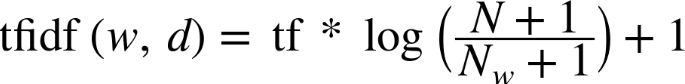



where N is the number of documents in the training set, Nw is the number of documents in the training set that the word w appears in, and tf (the term frequency) is the number of times that the word w appears in the query document d (the document you want to transform or encode).

Both classes also apply **L2 normalization** after computing the tf–idf representation; in other words, they **rescale the representation of each document to have Euclidean length 1**. Rescaling in this way means that the length of a document (the number of words) does not change the vectorized representation.

TF–IDF depends on the statistics of the training data (IDF). To make sure cross-validation or grid search is fair, we use a pipeline so that IDF is computed only on the training folds, and then applied safely to validation/test folds.

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression())

param_grid = {'logisticregression__C':[0.001, 0.01, 0.1, 1, 100]}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidfvectorizer',
                                        TfidfVectorizer(min_df=5)),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': [0.001, 0.01, 0.1, 1, 100]})

In [34]:
print("Best Cross-Validation Score: {:.2f}".format(grid.best_score_))

Best Cross-Validation Score: 0.89


In this case, tf–idf had no impact. We can also inspect which words tf–idf found most important.

Keep in mind that the tf–idf scaling is meant to find words that distinguish documents, but it is a purely unsupervised technique. So, “important” here does not necessarily relate to the “positive review” and “negative review” labels we are interested in.

First, we extract the TfidfVectorizer from the pipeline

In [35]:
vectorizer = grid.best_estimator_.named_steps["tfidfvectorizer"]

# transform the training dataset
X_train = vectorizer.transform(text_train)
print("X_train: \n{}".format(repr(X_train)))

X_train: 
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3354014 stored elements and shape (25000, 27271)>


In [36]:
# find maximum value for each of the features over the dataset
max_value = X_train.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()
# get feature names
feature_names = np.array(vectorizer.get_feature_names_out())

print("Features with lowest tfidf:\n{}".format(feature_names[sorted_by_tfidf[:20]]))

print("Features with highest tfidf: \n{}".format(feature_names[sorted_by_tfidf[-20:]]))

Features with lowest tfidf:
['suplexes' 'gauche' 'hypocrites' 'oncoming' 'songwriting' 'galadriel'
 'emerald' 'mclaughlin' 'sylvain' 'oversee' 'cataclysmic' 'pressuring'
 'uphold' 'thieving' 'inconsiderate' 'ware' 'denim' 'reverting' 'booed'
 'spacious']
Features with highest tfidf: 
['gadget' 'sucks' 'zatoichi' 'demons' 'lennon' 'bye' 'dev' 'weller'
 'sasquatch' 'botched' 'xica' 'darkman' 'woo' 'casper' 'doodlebops'
 'smallville' 'wei' 'scanners' 'steve' 'pokemon']


TF–IDF finds words that are unique and frequent in a document. High TF–IDF words often identify specific movies/shows, while low TF–IDF words are either too common or too rare. For sentiment classification, the truly useful words are those that signal sentiment, not just content.

We can also find the words that have low inverse document frequency, those that appear frequently and are therefore deemed less important. The inverse document frequency values found on the training set are stored in the idf_ attribute

In [37]:
sorted_by_idf = np.argsort(vectorizer.idf_)
print("Features with lowest idf:\n{}".format(feature_names[sorted_by_idf[:100]]))

Features with lowest idf:
['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'have' 'one' 'be' 'film' 'are' 'you' 'all'
 'at' 'an' 'by' 'so' 'from' 'like' 'who' 'they' 'there' 'if' 'his' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'good' 'can' 'more' 'when'
 'time' 'up' 'very' 'even' 'only' 'no' 'would' 'my' 'see' 'really' 'story'
 'which' 'well' 'had' 'me' 'than' 'much' 'their' 'get' 'were' 'other'
 'been' 'do' 'most' 'don' 'her' 'also' 'into' 'first' 'made' 'how' 'great'
 'because' 'will' 'people' 'make' 'way' 'could' 'we' 'bad' 'after' 'any'
 'too' 'then' 'them' 'she' 'watch' 'think' 'acting' 'movies' 'seen' 'its'
 'him']


As expected, these are mostly English stopwords like "the" and "no". But some are clearly domain-specific to the movie reviews, like "movie", "film", "time", "story", and so on. Interestingly, "good", "great", and "bad" are also among the most frequent and therefore “least relevant” words according to the tf–idf measure, even though we might expect these to be very important for our sentiment analysis task.

# Investigating Model Coefficients

 we can look in a bit more detail into what our logistic regression model actually learned from the data. Because there are so many features—27,271 after removing the infrequent ones—we clearly cannot look at all of the coefficients at the same time. However, we can look at the largest coefficients, and see which words these correspond to. We will use the last model that we trained, based on the tf–idf features.



The following bar chart shows the 25 largest and 25 smallest coefficients of the logistic regression model, with the bars showing the size of each coefficient.

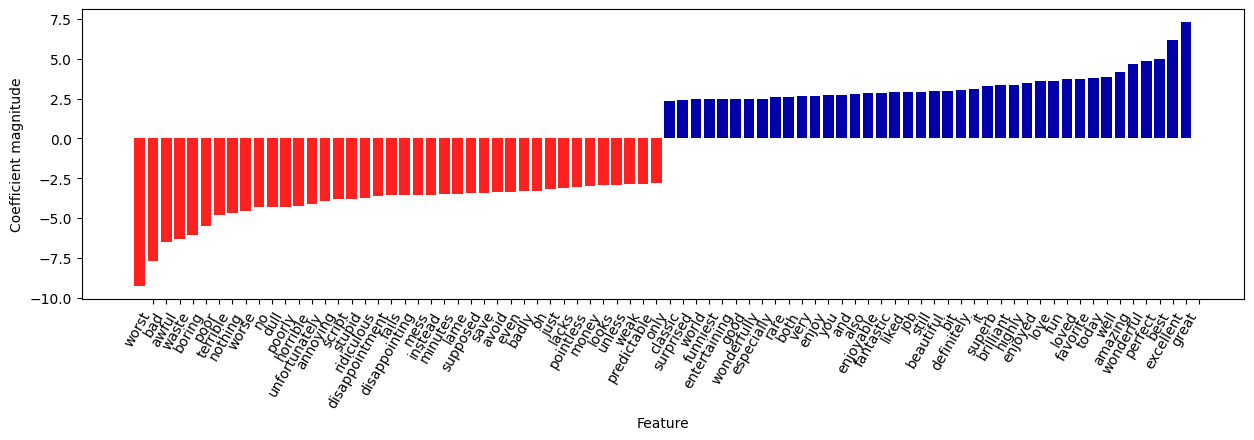

In [38]:
import mglearn

mglearn.tools.visualize_coefficients(
    grid.best_estimator_.named_steps["logisticregression"].coef_,
    feature_names, n_top_features=40)

The negative coefficients on the left belong to words that according to the model are indicative of negative reviews, while the positive coefficients on the right belong to words that according to the model indicate positive reviews.

Most of the terms are quite intuitive, like "worst", "waste", "disappointment", and "boring" indicating bad movie reviews, while "excellent", "wonderful", "enjoyable", and "brilliant" indicate positive movie reviews. Some words are slightly less clear, like "bit", "job", and "today", but these might be part of phrases like “good job” or “best today.”

# Bag-of-Words with More Than One Word (n-Grams)

One of the main disadvantages of using a bag-of-words representation is that word order is completely discarded.

Therefore, the two strings “it’s bad, not good at all” and “it’s good, not bad at all” have exactly the same representation, even though the meanings are inverted.

There is a way of capturing context when using a bag-of-words representation, by not only considering the counts of single tokens, but also the counts of pairs or triplets of tokens that appear next to each other.

Pairs of tokens are known as **bigrams**, triplets of tokens are known as **trigrams**, and more generally sequences of tokens are known as **n-grams**.

 We can change the range of tokens that are considered as features by changing the **ngram_range** parameter of CountVectorizer or TfidfVectorizer.

 * The **ngram_range** parameter is a tuple, consisting of the minimum length and the maximum length of the sequences of tokens that are considered.

 Below is an example using the toy dataset we used earlier:



In [39]:
print("bards_words:\n{}".format(bards_words))

bards_words:
['The fool doth think he is wise,', 'but the wise man knows himself to be a fool']


The default is to create one feature per sequence of tokens that is at least one token long and at most one token long, or in other words exactly one token long (single tokens are also called **unigrams**)

In [40]:
cv = CountVectorizer(ngram_range=(1, 1))
cv.fit(bards_words)

print("Vocabulary Size: {}".format(len(cv.vocabulary_)))
print("Vocabulary: \n{}".format(cv.get_feature_names_out()))

Vocabulary Size: 13
Vocabulary: 
['be' 'but' 'doth' 'fool' 'he' 'himself' 'is' 'knows' 'man' 'the' 'think'
 'to' 'wise']


To look only at bigrams that is, only at sequences of two tokens following each other, we can set ngram_range to (2, 2).

In [41]:
cv = CountVectorizer(ngram_range=(2, 2))
cv.fit(bards_words)

print("Vocabulary Size: {}".format(len(cv.vocabulary_)))
print("Vocabulary: \n{}".format(cv.get_feature_names_out()))

Vocabulary Size: 14
Vocabulary: 
['be fool' 'but the' 'doth think' 'fool doth' 'he is' 'himself to'
 'is wise' 'knows himself' 'man knows' 'the fool' 'the wise' 'think he'
 'to be' 'wise man']


Using longer sequences of tokens usually results in many more features, and in more specific features. There is no common bigram between the two phrases in bard_words.

In [42]:
print("Transformed data (dense):\n{}".format(cv.transform(bards_words).toarray()))

Transformed data (dense):
[[0 0 1 1 1 0 1 0 0 1 0 1 0 0]
 [1 1 0 0 0 1 0 1 1 0 1 0 1 1]]


Single words (unigrams) are essential because they already carry meaning. Adding two-word phrases (bigrams) usually improves performance by capturing context like “not good”. Longer word sequences can capture even more detail, but they massively increase the number of features and often cause overfitting because many such phrases appear very rarely. Although real language limits how many n-grams actually occur, higher n-grams still create large feature spaces and must be used carefully.

Below is what using unigrams, bigrams, and trigrams on bards_words looks like

In [43]:
cv = CountVectorizer(ngram_range=(1, 3))
cv.fit(bards_words)

print("Vocabulary size: {}".format(len(cv.vocabulary_)))
print("Vocabulary:\n{}".format(cv.get_feature_names_out()))

Vocabulary size: 39
Vocabulary:
['be' 'be fool' 'but' 'but the' 'but the wise' 'doth' 'doth think'
 'doth think he' 'fool' 'fool doth' 'fool doth think' 'he' 'he is'
 'he is wise' 'himself' 'himself to' 'himself to be' 'is' 'is wise'
 'knows' 'knows himself' 'knows himself to' 'man' 'man knows'
 'man knows himself' 'the' 'the fool' 'the fool doth' 'the wise'
 'the wise man' 'think' 'think he' 'think he is' 'to' 'to be' 'to be fool'
 'wise' 'wise man' 'wise man knows']


Now we can  try out the TfidfVectorizer on the IMDb movie review data and find the best setting of n-gram range using a grid search.

In [44]:
pipe = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression())

param_grid = {"logisticregression__C":[0.001, 0.01, 0.1, 1, 10, 100],
              "tfidfvectorizer__ngram_range":[(1, 1), (1, 2), (1, 3)]}

In [45]:
# running the grid search takes a long time because of the
# relatively large grid and the inclusion of trigrams
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidfvectorizer',
                                        TfidfVectorizer(min_df=5)),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': [0.001, 0.01, 0.1, 1, 10,
                                                   100],
                         'tfidfvectorizer__ngram_range': [(1, 1), (1, 2),
                                                          (1, 3)]})

In [46]:
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters:\n{}".format(grid.best_params_))

Best cross-validation score: 0.91
Best parameters:
{'logisticregression__C': 100, 'tfidfvectorizer__ngram_range': (1, 3)}


We can see from the results, we improved performance by a bit more than a percent by adding bigram and trigram features.

We can visualize the cross-validation accuracy as a function of the ngram_range and C parameter as a heat map.

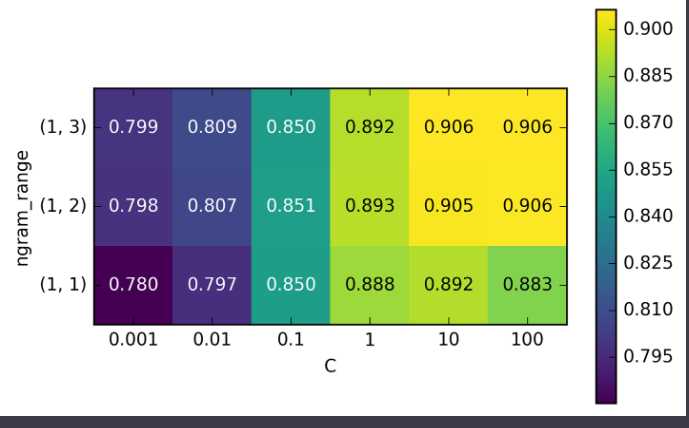

From the heat map we can see that using bigrams increases performance quite a bit, while adding trigrams only provides a very small benefit in terms of accuracy.

 To understand better how the model improved, we can visualize the important coefficient for the best model, which includes unigrams, bigrams, and trigrams.

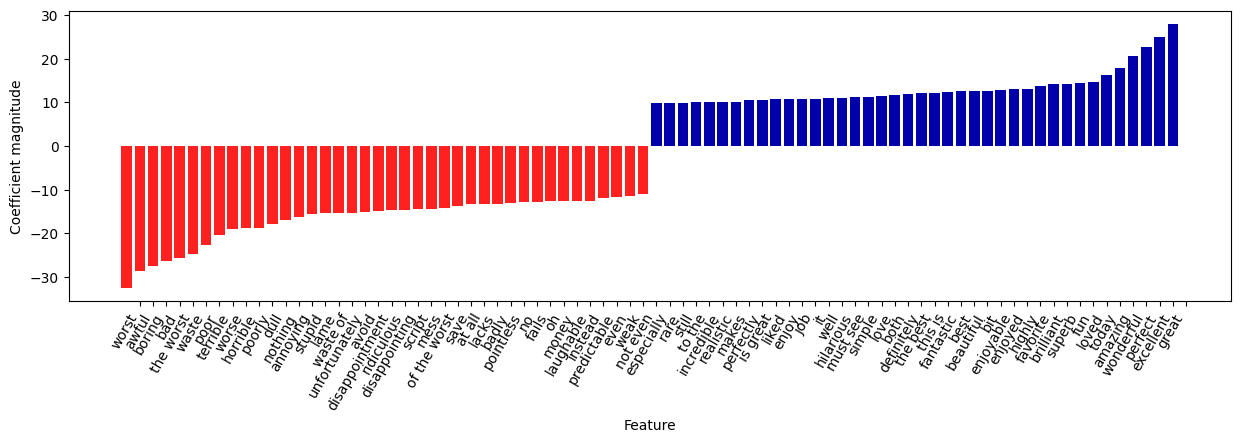

In [47]:
# extract feature names and coefficients
vect = grid.best_estimator_.named_steps['tfidfvectorizer']
feature_names = np.array(vect.get_feature_names_out())
coef = grid.best_estimator_.named_steps['logisticregression'].coef_
mglearn.tools.visualize_coefficients(coef, feature_names, n_top_features=40)

There are particularly interesting features containing 2 words.

we’ll visualize only trigrams, to provide further insight into why these features are helpful. Many of the useful bigrams and trigrams consist of common words that would not be informative on their own, as in the phrases "none of the", "the only good", "on and on", "this is one", "of the most", and so on. However, the impact of these features is quite limited compared to the importance of the unigram features.

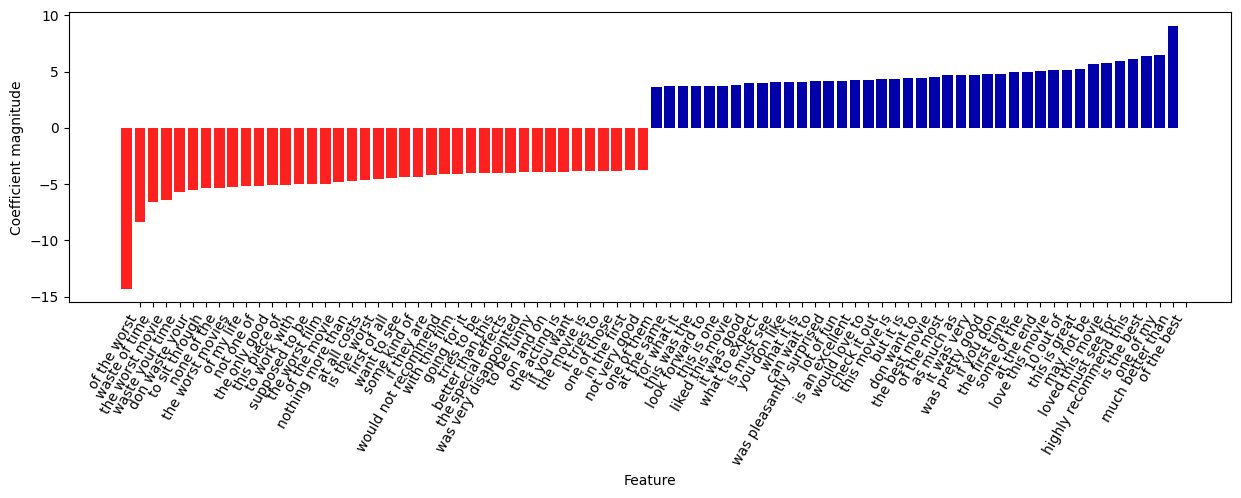

In [48]:
# find 3-gram features
mask = np.array([len(feature.split(" ")) for feature in feature_names]) == 3
# visualize only 3-gram features
mglearn.tools.visualize_coefficients(coef.ravel()[mask],
                                     feature_names[mask], n_top_features=40)

# Advanced Tokenization, Stemming, and Lemmatization

In text feature extraction methods such as CountVectorizer and TfidfVectorizer, tokenization is a basic process that defines what is considered a word. However, simple tokenization often treats different forms of the same word such as singular and plural nouns or different verb forms as separate features. This increases the size of the vocabulary, causes overfitting, and reduces the model’s ability to generalize, even though these word forms have very similar meanings.

To address this issue, word normalization techniques are used to convert related word forms into a single representation. One such technique is **stemming**, which uses rule-based heuristics (for example, removing common suffixes) to reduce words to their stem. Another technique is **lemmatization**, which uses a dictionary of known word forms and considers the grammatical role of the word to convert it into a standardized form called a **lemma**. Both stemming and lemmatization aim to reduce semantic redundancy in text data and improve model performance. Another form of normalization is spelling correction, which can be useful but is not discussed further.

To get a better understanding of normalization, we'll compare a method for stemming the Porter stemmer, a widely used collection of heuristic rules to reduce words to stems (here imported from the nltk package) to lemmatization as implemented in the spacy package, spaCy’s lemmatization uses linguistic knowledge to produce meaningful base forms.

In [49]:
!pip install nltk spacy

In [50]:
!python -m spacy download en

⚠ As of spaCy v3.0, shortcuts like 'en' are deprecated. Please use the
full pipeline package name 'en_core_web_sm' instead.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 24.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


spaCy is an NLP library, and en_core_web_sm is a small pre-trained language model it uses for tokenization, lemmatization, and basic linguistic analysis.

In [51]:
import spacy
import nltk

print("SpaCy version: {}".format(spacy.__version__))
print("nltk version: {}".format(nltk.__version__))

SpaCy version: 3.8.11
nltk version: 3.9.1


In [52]:
# load spacy's English-language models
en_nlp = spacy.load('en_core_web_sm')

# instantiate nltk's Porter stemmer
stemmer = nltk.stem.PorterStemmer()

# define function to compare lemmatization in spacy with stemming in nltk
def compare_normalization(doc):
    # tokenize document in spacy
    doc_spacy = en_nlp(doc)
    # print lemmas found by spacy
    print("Lemmatization:")
    print([token.lemma_ for token in doc_spacy])
    # print tokens found by Porter stemmer
    print("Stemming:")
    print([stemmer.stem(token.norm_.lower()) for token in doc_spacy])

In [53]:
compare_normalization("Our meeting today was worse than yesterday, "
                       "I'm scared of meeting the clients tomorrow.")

Lemmatization:
['our', 'meeting', 'today', 'be', 'bad', 'than', 'yesterday', ',', 'I', 'be', 'scared', 'of', 'meet', 'the', 'client', 'tomorrow', '.']
Stemming:
['our', 'meet', 'today', 'wa', 'wors', 'than', 'yesterday', ',', 'i', 'am', 'scare', 'of', 'meet', 'the', 'client', 'tomorrow', '.']


Stemming is always restricted to trimming the word to a stem, so "was" becomes "wa", while lemmatization can retrieve the correct base verb form, "be". Similarly, lemmatization can normalize "worse" to "bad", while stemming produces "wors". Another major difference is that stemming reduces both occurrences of "meeting" to "meet". Using lemmatization, the first occurrence of "meeting" is recognized as a noun and left as is, while the second occurrence is recognized as a verb and reduced to "meet".

In general, lemmatization is a much more involved process than stemming, but it usually produces better results than stemming when used for normalizing tokens for machine learning.

Scikit-learn implements neither form of normalization, CountVectorizer allows specifying your own tokenizer to convert each document into a list of tokens using the tokenizer parameter. We can use the lemmatization from spacy to create a callable that will take a string and produce a list of lemmas

In [54]:
# Technicality: we want to use the regexp-based tokenizer
# that is used by CountVectorizer and only use the lemmatization
# from spacy. To this end, we replace en_nlp.tokenizer (the spacy tokenizer)
# with the regexp-based tokenization.
from sklearn.feature_extraction.text import CountVectorizer
import re
import spacy
from spacy.tokens import Doc # Import Doc to create Doc objects from words

# regexp used in CountVectorizer
regexp = re.compile('(?u)\\b\\w\\w+\\b')

# load spacy language model
en_nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# replace the tokenizer with a function that creates a Doc object from regexp matches
# The tokenizer should take text and return a Doc object.
# The Doc object can be created from a list of words using Doc(vocab, words=...)
en_nlp.tokenizer = lambda text: Doc(en_nlp.vocab, words=regexp.findall(text))

# create a custom tokenizer using the spacy document processing pipeline
# (now using our own tokenizer)
def custom_tokenizer(document):
    doc_spacy = en_nlp(document)
    return [token.lemma_ for token in doc_spacy]

# define a count vectorizer with the custom tokenizer
lemma_vect = CountVectorizer(tokenizer=custom_tokenizer, min_df=5)

In this setup, we combine CountVectorizer’s tokenization with spaCy’s lemmatization to create a bag-of-words model with normalized words. First, a regular expression (the same used by CountVectorizer) splits the input document into tokens, selecting only words of two or more characters. These tokens are converted into a spaCy Doc, which allows access to linguistic features such as lemmatization. A custom tokenizer function processes the document through this spaCy pipeline and returns the lemmas of all tokens. Finally, these lemmas are fed into CountVectorizer, which treats each lemma as a feature and constructs a bag-of-words representation for each document. This approach ensures that tokenization is consistent with CountVectorizer, while normalization via lemmatization reduces vocabulary size and improves model generalization.

We can now transform the data and inspect the vocabulary size.

In [55]:
# transform text_train using CountVectorizer with lemmatization
X_train_lemma = lemma_vect.fit_transform(text_train)

print("X_train_lemma.shape: {}".format(X_train_lemma.shape))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


X_train_lemma.shape: (25000, 21581)


As you can see from the output, lemmatization reduced the number of features from 27,271 (with the standard CountVectorizer processing) to 21,581. Lemmatization can be seen as a kind of regularization, as it conflates certain features. Therefore, we expect lemmatization to improve performance most when the dataset is small.

In [56]:
# build a grid search using only 1% of the data as the training set
from sklearn.model_selection import StratifiedShuffleSplit

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.99,
                            train_size=0.01, random_state=0)
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=cv)
# perform grid search with standard CountVectorizer
grid.fit(X_train, y_train)
print("Best cross-validation score "
      "(standard CountVectorizer): {:.3f}".format(grid.best_score_))
# perform grid search with lemmatization
grid.fit(X_train_lemma, y_train)
print("Best cross-validation score "
      "(lemmatization): {:.3f}".format(grid.best_score_))

Best cross-validation score (standard CountVectorizer): 0.772
Best cross-validation score (lemmatization): 0.728


In this case, lemmatization provided a modest improvement in performance. As with many of the different feature extraction techniques, the result varies depending on the dataset. Lemmatization and stemming can sometimes help in building better (or at least more compact) models.

# Topic Modeling and Document Clustering

Topic modeling is an unsupervised technique used to assign documents to one or more topics. When each document is assigned a single topic, the task is equivalent to clustering the documents. When documents can belong to multiple topics, decomposition methods like PCA or NMF can be applied, where each component corresponds to a topic and the coefficients indicate how strongly a document relates to each topic. This approach allows analyzing the structure of text data and grouping documents based on shared patterns of word usage.

# Latent Dirichlet Allocation (LDA)

Latent Dirichlet Allocation (LDA) is a popular topic modeling method that identifies groups of words that frequently appear together, treating each document as a mixture of multiple topics. LDA topics may not always match human-understandable topics; they are patterns in word co-occurrence, similar to components in PCA or NMF. For example, in a news dataset, LDA might find topics corresponding to sports, politics, finance, or even author-specific word patterns. The model captures statistical relationships between words, helping to represent documents as mixtures of these latent topics.

We can apply LDA to our movie review dataset to see how it works in practice. For unsupervised text document models, it is often good to remove very common words, as they might otherwise dominate the analysis. We’ll remove words that appear in at least 15 percent of the documents, and we’ll limit the bag-of-words model to the 10,000 words that are most common after removing the top 15 percent

In [57]:
vect = CountVectorizer(max_features=10000, max_df=0.15)
X = vect.fit_transform(text_train)

We will learn a topic model with 10 topics, which is few enough that we can look at all of them. Similarly to the components in NMF, topics don’t have an inherent ordering, and changing the number of topics will change all of the topics.

We’ll use the "batch" learning method, which is somewhat slower than the default ("online") but usually provides better results, and increase "max_iter", which can also lead to better models.

* Batch Learning --> A learning method in which the model is updated using the entire dataset at once in each iteration.

* Online Learning --> A learning method in which the model is updated incrementally using small subsets (mini-batches) of the data.

In [58]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=10,
                                learning_method="batch",
                                max_iter=25,
                                random_state=0) # since at initialization randomly assign words in documents to topics


# We build the model and transform the data in one step
# Computing transform takes some time,
# and we can save time by doing both at once
document_topics = lda.fit_transform(X)

Like in the other decomposition methods LatentDirichletAllocation has a components_ attribute that stores how important each word is for each topic. The size of components_ is (n_topics, n_words)

In [59]:
print("lda.components_.shape: {}".format(lda.components_.shape))

lda.components_.shape: (10, 10000)


To understand better what the different topics mean, we will look at the most important words for each of the topics.

In [60]:
# For each topic (a row in the components_), sort the features (ascending)
# Invert rows with [:, ::-1] to make sorting descending
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]
# Get the feature names from the vectorizer
feature_names = np.array(vect.get_feature_names_out())

In [61]:
# Print out the 10 topics:
mglearn.tools.print_topics(topics=range(10), feature_names=feature_names,
                           sorting=sorting, topics_per_chunk=5, n_words=10)

topic 0       topic 1       topic 2       topic 3       topic 4       
--------      --------      --------      --------      --------      
family        music         comedy        world         funny         
father        role          role          war           thing         
young         musical       cast          us            worst         
girl          cast          performance   american      didn          
mother        performance   actor         our           nothing       
woman         songs         plays         own           actually      
wife          song          john          history       want          
old           dance         played        documentary   10            
son           play          james         real          guy           
home          comedy        funny         human         re            


topic 5       topic 6       topic 7       topic 8       topic 9       
--------      --------      --------      --------      --------      
dire

Judging from the important words, topic 3 seems to be about historical and war movies, topic 9 seems to be about horror and thriller movies.Using only 10 topics, each of the topics needs to be very broad, so that they can together cover all the different kinds of reviews in our dataset.

we will learn another model, this time with 100 topics. Using more topics makes the analysis much harder, but makes it more likely that topics can specialize to interesting subsets of the data.

In [62]:
lda100 = LatentDirichletAllocation(n_components=100, learning_method="batch",
                                   max_iter=25, random_state=0)
document_topics100 = lda100.fit_transform(X)

Looking at all 100 topics would be a bit overwhelming, so we selected some interesting and representative topics.

In [63]:
topics = np.array([7, 16, 24, 25, 28, 36, 37, 45, 51, 53, 54, 63, 89, 97])

sorting = np.argsort(lda100.components_, axis=1)[:, ::-1]
feature_names = np.array(vect.get_feature_names_out())
mglearn.tools.print_topics(topics=topics, feature_names=feature_names,
                           sorting=sorting, topics_per_chunk=5, n_words=20)

topic 7       topic 16      topic 24      topic 25      topic 28      
--------      --------      --------      --------      --------      
werewolf      rock          tony          rape          ted           
vampire       chris         al            richard       john          
moon          ring          accent        lynch         barbara       
bat           taylor        gary          doctor        bill          
stephen       jones         american      hardy         stanwyck      
grey          down          pacino        stan          robert        
wolf          roberts       gangster      straight      sally         
village       sandra        cooper        laurel        code          
zone          angle         accents       mummy         lily          
vampires      lloyd         godfather     canadian      woman         
vegas         buffalo       david         ollie         young         
germans       before        mafia         desert        wayne         
twilig

The topics we extracted this time seem to be more specific, though many are hard to interpret. Topic 7 seems to be about horror movies and thrillers; topic 53 seem to capture bad reviews.

If we want to make further inferences using the topics that were discovered, we should confirm the intuition we gained from looking at the highest-ranking words for each topic by looking at the documents that are assigned to these topics.

For example, topic 36 seems to be about music. Let’s check which kinds of reviews are assigned to this topic.

In [64]:
# sort by weight of "music" topic 36
music = np.argsort(document_topics100[:, 36])[::-1]
# print the five documents where the topic is most important
for i in music[:10]:
    # show first two sentences
    print(b".".join(text_train[i].split(b".")[:2]) + b".\n")

b'The best part of An American In Paris is the lengthy ballet sequence at the end, where Gene Kelly and Leslie Caron are the living personification of several major painters. Kelly has earlier been established as a pavement artist in Paris, so the sequence is the logical ending to a musical bursting with life and energy, Gershwin tunes, and cast members like Georges Guetary and Oscar Levant.\n'
b'Entertaining musical where Nathan Detroit needs $1,000.00 to get up a floating crap game so he entices Sky Masterson to try and get salvation army girl, played by Jean Simmons, to go with Masterson to Havana.\n'
b'This movie will always be a Broadway and Movie classic, as long as there are still people who sing, dance, and act..\n'
b'An American In Paris is an integrated musical, meaning that the songs and dances blend perfectly with the story. The film was inspired by the 1928 orchestral composition by George Gershwin.\n'
b'Throughly enjoy all the musical numbers each time I see this movie. N

Another interesting way to inspect the topics is to see how much weight each topic gets overall, by summing the document_topics over all reviews. We name each topic by the two most common words.

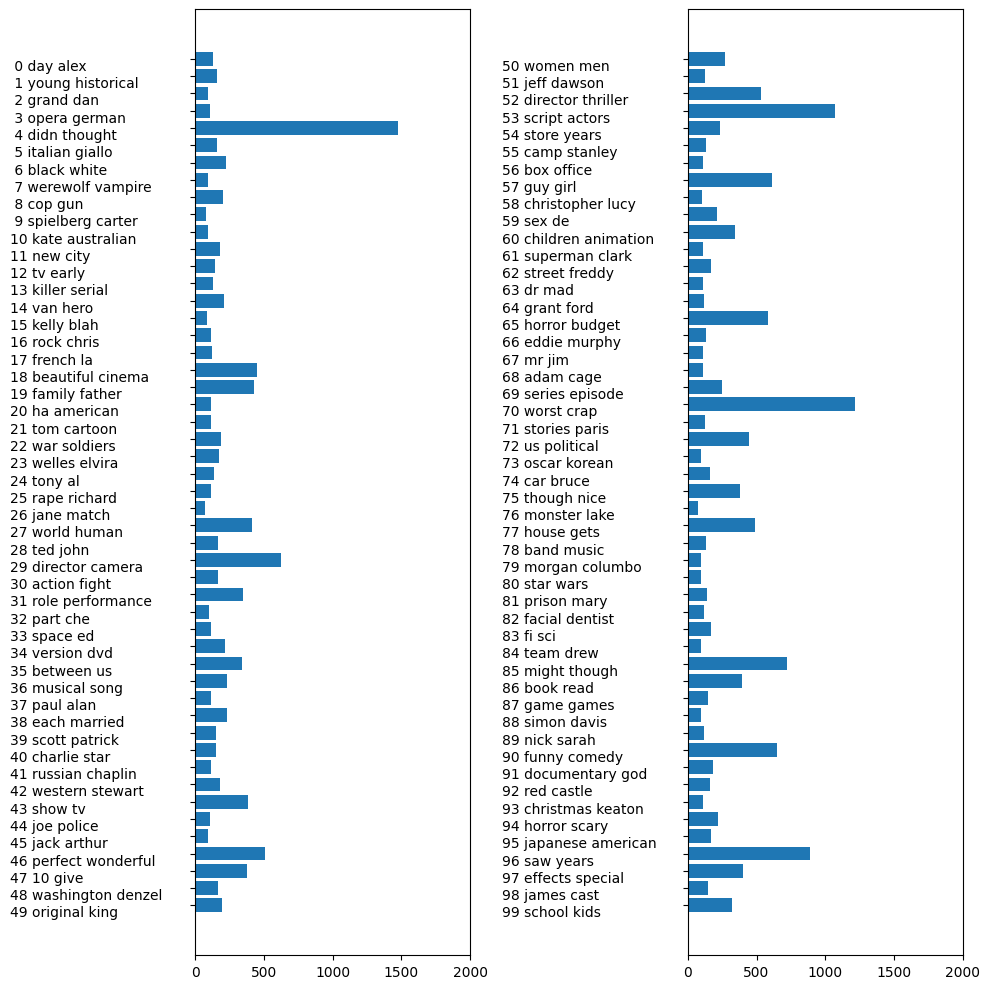

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 10))
topic_names = ["{:>2} ".format(i) + " ".join(words)
               for i, words in enumerate(feature_names[sorting[:, :2]])]
# two column bar chart:
for col in [0, 1]:
    start = col * 50
    end = (col + 1) * 50
    ax[col].barh(np.arange(50), np.sum(document_topics100, axis=0)[start:end])
    ax[col].set_yticks(np.arange(50))
    ax[col].set_yticklabels(topic_names[start:end], ha="left", va="top")
    ax[col].invert_yaxis()
    ax[col].set_xlim(0, 2000)
    yax = ax[col].get_yaxis()
    yax.set_tick_params(pad=130)
plt.tight_layout()

Topic models like LDA are interesting methods to understand large text corpora in the absence of labels or, as here, even if labels are available. The LDA algorithm is randomized, though, and changing the random_state parameter can lead to quite different outcomes.

The topics produced by the LDA.transform method can also sometimes be used as a compact representation for supervised learning. This is particularly helpful when few training examples are available.